# District User Activation & Retention Analysis

## Project Objective

Analyze user activation, engagement, and retention across districts to evaluate product adoption and identify opportunities to improve long-term user growth using Python.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Data Understanding

In [ ]:
df = pd.read_csv("MOCK_DATA (1).csv")

df.head()

,user_id,district,signup_date,first_active_date,activity_date,sessions,session_duration_min,orders,total_spent,activated,retained_7d,retained_30d,platform,device,acquisition_source,age_group
0,1,C,11/11/2025,8/14/2025,11/6/2025,30,1.42,15,2046.23,True,True,True,iOS,Tablet,Social Media,45-54
1,2,E,5/8/2025,6/28/2025,5/22/2025,13,37.17,20,1041.81,False,True,True,iOS,Tablet,Referral,35-44
2,3,C,2/15/2025,2/2/2025,1/11/2025,18,17.57,17,2075.23,True,True,False,Web,Tablet,Organic,45-54
3,4,C,5/30/2025,2/25/2025,4/29/2025,22,149.01,1,2122.86,True,False,True,Android,Desktop,Organic,35-44
4,5,C,2/13/2025,7/29/2025,6/23/2025,22,120.76,0,3755.08,True,True,False,Web,Desktop,Paid Search,18-24


## Data Inspection

In [ ]:
df.shape

(1000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1000 non-null   int64  
 1   district              1000 non-null   object 
 2   signup_date           1000 non-null   object 
 3   first_active_date     1000 non-null   object 
 4   activity_date         1000 non-null   object 
 5   sessions              1000 non-null   int64  
 6   session_duration_min  1000 non-null   float64
 7   orders                1000 non-null   int64  
 8   total_spent           1000 non-null   float64
 9   activated             1000 non-null   bool   
 10  retained_7d           1000 non-null   bool   
 11  retained_30d          1000 non-null   bool   
 12  platform              1000 non-null   object 
 13  device                1000 non-null   object 
 14  acquisition_source    1000 non-null   object 
 15  age_group             

In [ ]:
df.isnull().sum()

,0
user_id,0
district,0
signup_date,0
first_active_date,0
activity_date,0
sessions,0
session_duration_min,0
orders,0
total_spent,0
activated,0


## Data Preprocessing

In [ ]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["first_active_date"] = pd.to_datetime(df["first_active_date"])
df["activity_date"] = pd.to_datetime(df["activity_date"])

In [ ]:
df["signup_month"] = df["signup_date"].dt.to_period("M")
df["activity_month"] = df["activity_date"].dt.to_period("M")

In [ ]:
df["signup_day"] = df["signup_date"].dt.day_name()
df["activity_day"] = df["activity_date"].dt.day_name()

## Key Performance Indicators (KPIs)

In [ ]:
total_users = df["user_id"].nunique()

dau = df.groupby("activity_date")["user_id"].nunique().mean()

mau = df.groupby("activity_month")["user_id"].nunique().mean()

activation_rate = df["activated"].mean()*100

retention_7 = df["retained_7d"].mean()*100

retention_30 = df["retained_30d"].mean()*100

avg_sessions = df["sessions"].mean()

avg_session_duration = df["session_duration_min"].mean()

avg_revenue = df["total_spent"].mean()

In [ ]:
print(f"Total Users : {total_users}")

print(f"Average DAU : {dau:.2f}")

print(f"Average MAU : {mau:.2f}")

print(f"Activation Rate : {activation_rate:.2f}%")

print(f"7-Day Retention : {retention_7:.2f}%")

print(f"30-Day Retention : {retention_30:.2f}%")

print(f"Average Sessions : {avg_sessions:.2f}")

print(f"Average Session Duration : {avg_session_duration:.2f} minutes")

print(f"Average Revenue per User : ₹{avg_revenue:.2f}")

Total Users : 1000
Average DAU : 2.92
Average MAU : 83.33
Activation Rate : 50.20%
7-Day Retention : 50.80%
30-Day Retention : 51.10%
Average Sessions : 15.28
Average Session Duration : 88.26 minutes
Average Revenue per User : ₹2507.70


## Exploratory Data Analysis

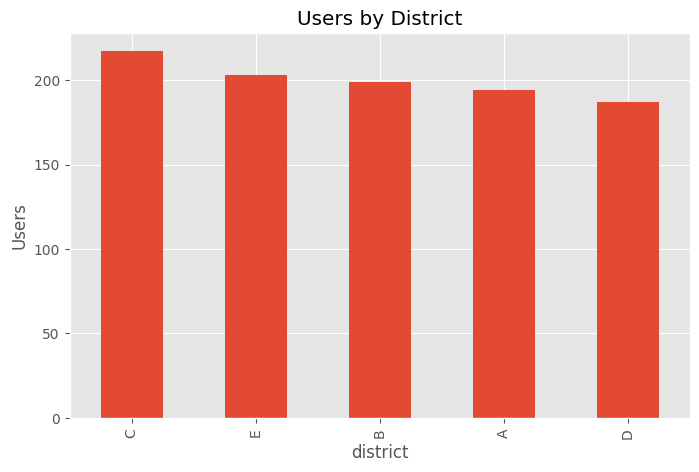

In [ ]:
district = (
    df.groupby("district")["user_id"]
    .count()
    .sort_values(ascending=False)
)

district.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Users by District")
plt.ylabel("Users")
plt.show()

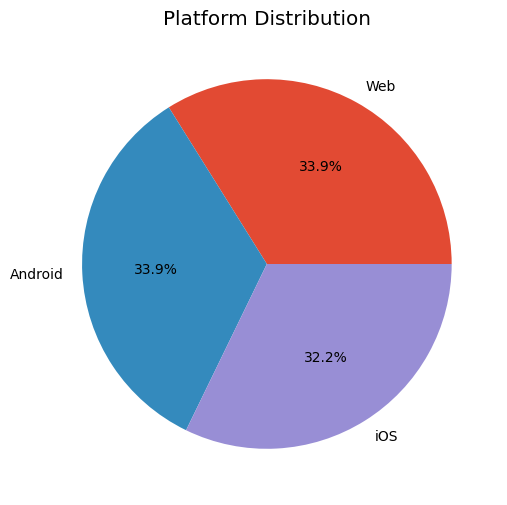

In [ ]:
df["platform"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Platform Distribution")
plt.show()

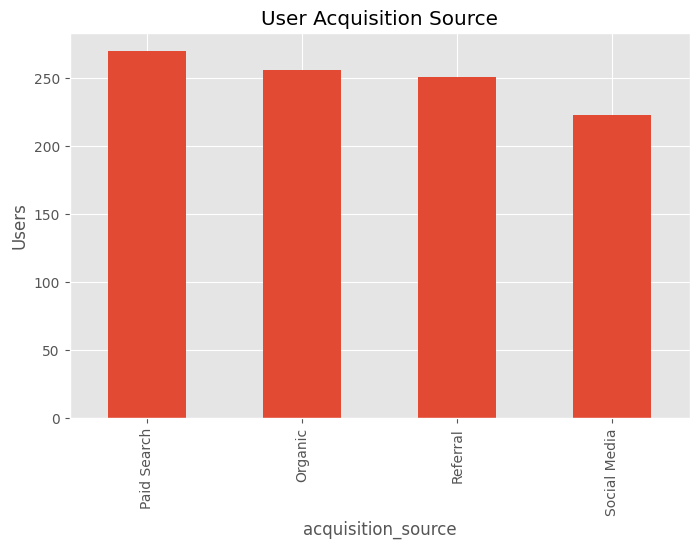

In [ ]:
df["acquisition_source"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("User Acquisition Source")
plt.ylabel("Users")
plt.show()

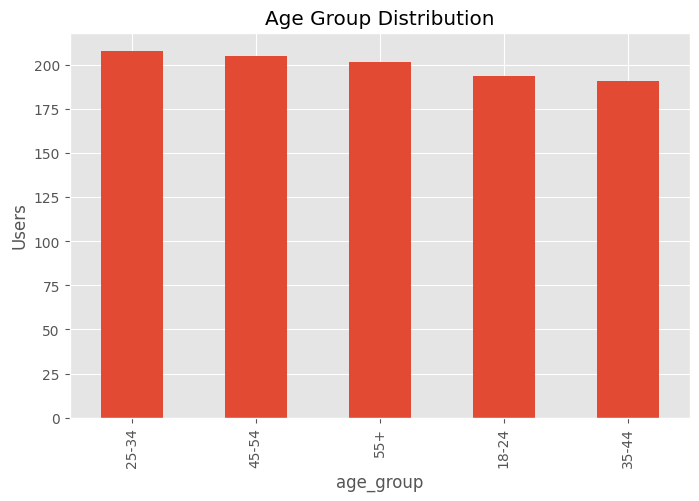

In [ ]:
df["age_group"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Age Group Distribution")
plt.ylabel("Users")
plt.show()

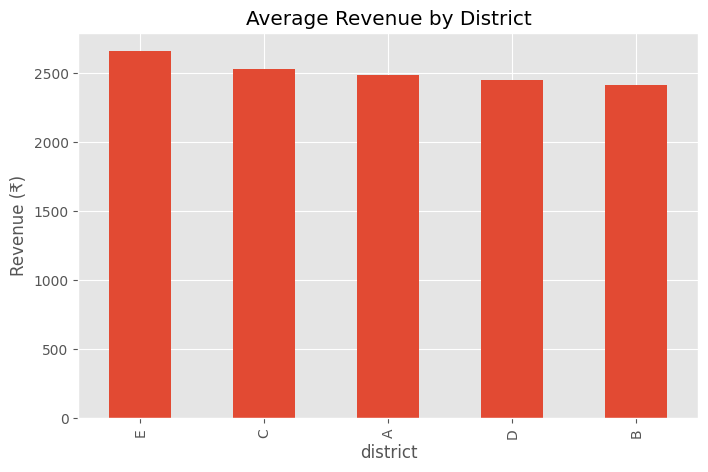

In [ ]:
revenue = (
    df.groupby("district")["total_spent"]
    .mean()
    .sort_values(ascending=False)
)

revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Revenue by District")
plt.ylabel("Revenue (₹)")
plt.show()

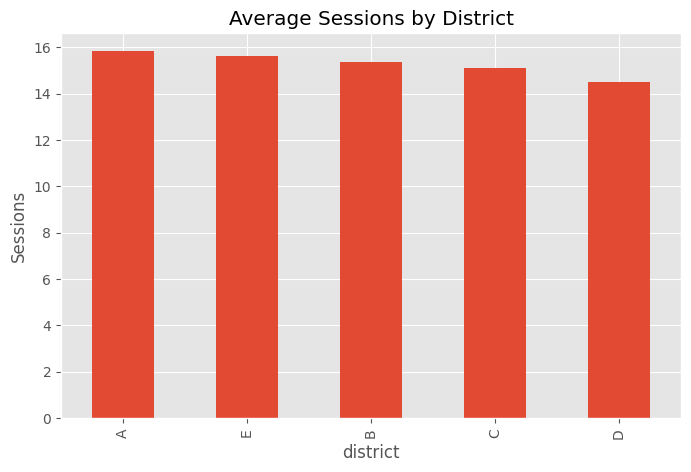

In [ ]:
sessions = (
    df.groupby("district")["sessions"]
    .mean()
    .sort_values(ascending=False)
)

sessions.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Sessions by District")
plt.ylabel("Sessions")
plt.show()

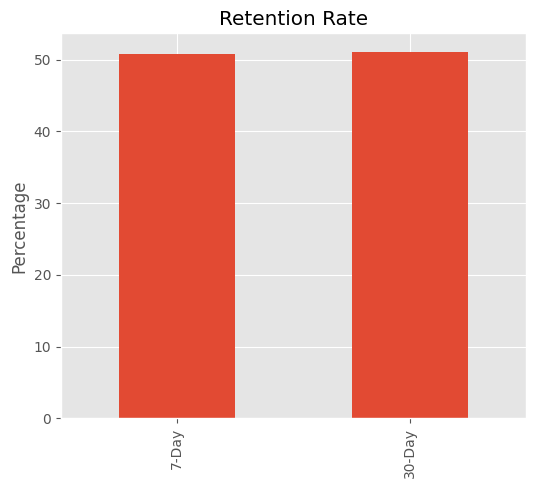

In [ ]:
retention = pd.Series(
    [
        retention_7,
        retention_30
    ],
    index=[
        "7-Day",
        "30-Day"
    ]
)

retention.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Retention Rate")
plt.ylabel("Percentage")
plt.show()

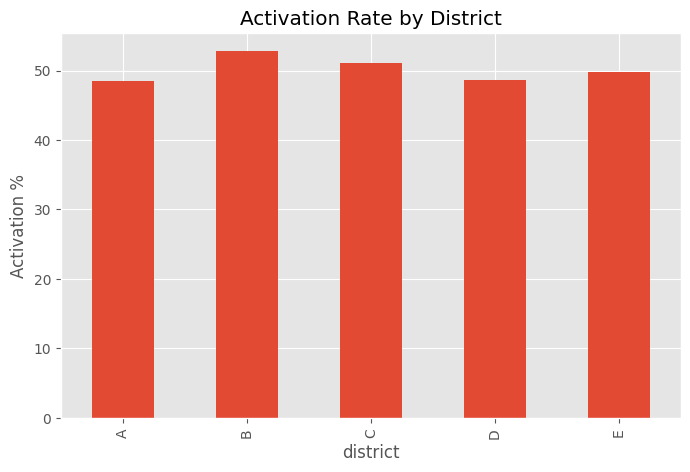

In [ ]:
activation = (
    df.groupby("district")["activated"]
    .mean()*100
)

activation.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Activation Rate by District")
plt.ylabel("Activation %")
plt.show()

# Business Insights

- District E has the highest average revenue per user, indicating strong monetization opportunities.

- District C has the largest user base, making it an important market for user engagement initiatives.

- Overall activation rate is approximately 50.2%, suggesting that nearly half of registered users become active.

- 7-day retention is around 50.8%, while 30-day retention remains at 51.1%, indicating relatively stable long-term engagement.

- Average users complete approximately 15 sessions with an average session duration of 88.3 minutes.

- Android, iOS, and Web users are almost evenly distributed, requiring consistent cross-platform product experience.

- Paid Search contributes the largest share of user acquisition, followed by Organic and Referral channels.

- User engagement is distributed across all age groups, with the 25–34 segment contributing the highest user volume.